Installing the relevant packages

In [22]:
!pip install yfinance pandas numpy matplotlib scipy openpyxl -q

In [23]:
import os
import warnings

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from scipy import stats

try:
  from google.colab import files
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

def download_file(path):
  if IN_COLAB:
    files.download(path)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

The assets to analyse

In [24]:
# Assets included in the event study

ASSETS = {
    # Commodity futures
    "Brent Crude": "BZ=F",
    "WTI Crude": "CL=F",
    "Natural Gas": "NG=F",

    # Integrated energy companies
    "Shell": "SHEL",
    "BP": "BP",
    "ExxonMobil": "XOM",
    "Chevron": "CVX",
    "TotalEnergies": "TTE",

    # Sector and related-industry ETFs
    "Energy ETF": "XLE",
    "Oil Services ETF": "OIH",
    "Airlines ETF": "JETS",
    "Utilities ETF": "XLU"
}

BENCHMARK = "SPY"

EVENT_WINDOWS = [1, 3, 5]

DAYS_BEFORE_EVENT = 5
DAYS_AFTER_EVENT = 5

print(f"Number of assets: {len(ASSETS)}")

Number of assets: 12


Creating the manual dataset of events



In [25]:
events_data = [

    # OPEC Decisions
    {
        "event_id": "E001",
        "date": "2020-04-12",
        "category": "OPEC decision",
        "commodity": "Oil",
        "event_type": "Production cut",
        "headline": "OPEC+ agrees record production cuts",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "OPEC"
    },
    {
        "event_id": "E002",
        "date": "2021-07-18",
        "category": "OPEC decision",
        "commodity": "Oil",
        "event_type": "Production increase",
        "headline": "OPEC+ agrees gradual production increase",
        "expected_direction": "bearish",
        "surprise_level": "Medium",
        "source": "OPEC"
    },
    {
        "event_id": "E003",
        "date": "2022-10-05",
        "category": "OPEC decision",
        "commodity": "Oil",
        "event_type": "Production cut",
        "headline": "OPEC+ announces major production cut",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "OPEC"
    },
    {
        "event_id": "E004",
        "date": "2023-04-02",
        "category": "OPEC decision",
        "commodity": "Oil",
        "event_type": "Voluntary production cut",
        "headline": "OPEC+ members announce voluntary cuts",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "OPEC"
    },
    {
        "event_id": "E005",
        "date": "2023-11-30",
        "category": "OPEC decision",
        "commodity": "Oil",
        "event_type": "Production cut extension",
        "headline": "OPEC+ extends voluntary production cuts",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "OPEC"
    },

    # Inventory Announcements
    {
        "event_id": "E006",
        "date": "2022-04-06",
        "category": "Inventory announcement",
        "commodity": "Oil",
        "event_type": "EIA inventories",
        "headline": "US crude inventories rise sharply",
        "expected_direction": "bearish",
        "surprise_level": "Medium",
        "source": "US EIA"
    },
    {
        "event_id": "E007",
        "date": "2022-10-19",
        "category": "Inventory announcement",
        "commodity": "Oil",
        "event_type": "EIA inventories",
        "headline": "US crude inventories fall unexpectedly",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "US EIA"
    },
    {
        "event_id": "E008",
        "date": "2023-06-14",
        "category": "Inventory announcement",
        "commodity": "Oil",
        "event_type": "EIA inventories",
        "headline": "US crude inventories increase more than forecast",
        "expected_direction": "bearish",
        "surprise_level": "Medium",
        "source": "US EIA"
    },
    {
        "event_id": "E009",
        "date": "2023-08-09",
        "category": "Inventory announcement",
        "commodity": "Oil",
        "event_type": "EIA inventories",
        "headline": "Large draw in US crude inventories",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "US EIA"
    },
    {
        "event_id": "E010",
        "date": "2024-01-31",
        "category": "Inventory announcement",
        "commodity": "Oil",
        "event_type": "EIA inventories",
        "headline": "Unexpected increase in crude inventories",
        "expected_direction": "bearish",
        "surprise_level": "Low",
        "source": "US EIA"
    },


    # Geopolitical Shocks
    {
        "event_id": "E011",
        "date": "2022-02-24",
        "category": "Geopolitical shock",
        "commodity": "Oil and gas",
        "event_type": "War",
        "headline": "Russia invades Ukraine",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },
    {
        "event_id": "E012",
        "date": "2023-10-07",
        "category": "Geopolitical shock",
        "commodity": "Oil",
        "event_type": "Conflict",
        "headline": "Israel-Hamas conflict begins",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },
    {
        "event_id": "E013",
        "date": "2024-01-12",
        "category": "Geopolitical shock",
        "commodity": "Oil",
        "event_type": "Military action",
        "headline": "US and UK launch strikes against Houthi targets",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "Public news reports"
    },
    {
        "event_id": "E014",
        "date": "2024-04-13",
        "category": "Geopolitical shock",
        "commodity": "Oil",
        "event_type": "Missile attack",
        "headline": "Iran launches direct attack on Israel",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },

    # Supply Disruptions
    {
        "event_id": "E015",
        "date": "2021-03-23",
        "category": "Supply disruption",
        "commodity": "Oil",
        "event_type": "Shipping",
        "headline": "Ever Given blocks the Suez Canal",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },
    {
        "event_id": "E016",
        "date": "2022-09-02",
        "category": "Supply disruption",
        "commodity": "Natural gas",
        "event_type": "Pipeline",
        "headline": "Nord Stream 1 remains shut",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },
    {
        "event_id": "E017",
        "date": "2022-06-08",
        "category": "Supply disruption",
        "commodity": "Natural gas",
        "event_type": "LNG outage",
        "headline": "Freeport LNG export terminal outage",
        "expected_direction": "bearish",
        "surprise_level": "High",
        "source": "Public news reports"
    },
    {
        "event_id": "E018",
        "date": "2024-03-18",
        "category": "Supply disruption",
        "commodity": "Oil",
        "event_type": "Refinery outage",
        "headline": "Major refinery disruption reported",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "Public news reports"
    },

    # Weather Disruptions
    {
        "event_id": "E019",
        "date": "2021-08-29",
        "category": "Weather disruption",
        "commodity": "Oil",
        "event_type": "Hurricane",
        "headline": "Hurricane Ida disrupts Gulf production",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },
    {
        "event_id": "E020",
        "date": "2022-09-28",
        "category": "Weather disruption",
        "commodity": "Oil",
        "event_type": "Hurricane",
        "headline": "Hurricane Ian impacts US energy infrastructure",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "Public news reports"
    },
    {
        "event_id": "E021",
        "date": "2024-05-28",
        "category": "Weather disruption",
        "commodity": "Natural gas",
        "event_type": "Heatwave",
        "headline": "US heatwave boosts natural gas demand expectations",
        "expected_direction": "bullish",
        "surprise_level": "Low",
        "source": "Public news reports"
    },


    # Government Interventions
    {
        "event_id": "E022",
        "date": "2022-03-31",
        "category": "Government intervention",
        "commodity": "Oil",
        "event_type": "SPR release",
        "headline": "US announces Strategic Petroleum Reserve release",
        "expected_direction": "bearish",
        "surprise_level": "High",
        "source": "US government"
    },
    {
        "event_id": "E023",
        "date": "2022-10-19",
        "category": "Government intervention",
        "commodity": "Oil",
        "event_type": "SPR release",
        "headline": "Further Strategic Petroleum Reserve release announced",
        "expected_direction": "bearish",
        "surprise_level": "Medium",
        "source": "US government"
    },


    # Demand Shocks

    {
        "event_id": "E024",
        "date": "2020-03-11",
        "category": "Demand shock",
        "commodity": "Oil",
        "event_type": "Pandemic",
        "headline": "WHO declares COVID-19 pandemic",
        "expected_direction": "bearish",
        "surprise_level": "High",
        "source": "WHO"
    },
    {
        "event_id": "E025",
        "date": "2022-12-07",
        "category": "Demand shock",
        "commodity": "Oil",
        "event_type": "China reopening",
        "headline": "China eases COVID restrictions",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },

    # Natural Gas
    {
        "event_id": "E026",
        "date": "2022-07-11",
        "category": "Natural gas",
        "commodity": "Natural gas",
        "event_type": "Pipeline maintenance",
        "headline": "Nord Stream maintenance begins",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "Public news reports"
    },
    {
        "event_id": "E027",
        "date": "2022-09-26",
        "category": "Natural gas",
        "commodity": "Natural gas",
        "event_type": "Pipeline damage",
        "headline": "Nord Stream explosions reported",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Public news reports"
    },


    # Other Events

    {
        "event_id": "E028",
        "date": "2023-09-05",
        "category": "Supply disruption",
        "commodity": "Oil",
        "event_type": "Saudi production cut",
        "headline": "Saudi Arabia extends voluntary production cut",
        "expected_direction": "bullish",
        "surprise_level": "High",
        "source": "Saudi Ministry of Energy"
    },
    {
        "event_id": "E029",
        "date": "2024-06-02",
        "category": "OPEC decision",
        "commodity": "Oil",
        "event_type": "Production policy",
        "headline": "OPEC+ agrees phased production adjustment",
        "expected_direction": "bearish",
        "surprise_level": "Medium",
        "source": "OPEC"
    },
    {
        "event_id": "E030",
        "date": "2024-10-02",
        "category": "Geopolitical shock",
        "commodity": "Oil",
        "event_type": "Regional conflict",
        "headline": "Escalation of Middle East tensions",
        "expected_direction": "bullish",
        "surprise_level": "Medium",
        "source": "Public news reports"
    }
]

events = pd.DataFrame(events_data)

events["date"] = pd.to_datetime(events["date"])

events = events.sort_values("date").reset_index(drop=True)

display(events)

,event_id,date,category,commodity,event_type,headline,expected_direction,surprise_level,source
0,E024,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO
1,E001,2020-04-12,OPEC decision,Oil,Production cut,OPEC+ agrees record production cuts,bullish,High,OPEC
2,E015,2021-03-23,Supply disruption,Oil,Shipping,Ever Given blocks the Suez Canal,bullish,High,Public news reports
3,E002,2021-07-18,OPEC decision,Oil,Production increase,OPEC+ agrees gradual production increase,bearish,Medium,OPEC
4,E019,2021-08-29,Weather disruption,Oil,Hurricane,Hurricane Ida disrupts Gulf production,bullish,High,Public news reports
5,E011,2022-02-24,Geopolitical shock,Oil and gas,War,Russia invades Ukraine,bullish,High,Public news reports
6,E022,2022-03-31,Government intervention,Oil,SPR release,US announces Strategic Petroleum Reserve release,bearish,High,US government
7,E006,2022-04-06,Inventory announcement,Oil,EIA inventories,US crude inventories rise sharply,bearish,Medium,US EIA
8,E017,2022-06-08,Supply disruption,Natural gas,LNG outage,Freeport LNG export terminal outage,bearish,High,Public news reports
9,E026,2022-07-11,Natural gas,Natural gas,Pipeline maintenance,Nord Stream maintenance begins,bullish,Medium,Public news reports


Downloading the market data from Yahoo Finance using the relevant tickers. It downloads the date and price for every asset.

In [26]:
start_date = (events["date"].min() - pd.Timedelta(days=90))

end_date = (events["date"].max() + pd.Timedelta(days=30))

tickers = list(ASSETS.values()) + [BENCHMARK]

print(f"Downloading prices from {start_date.date()} to {end_date.date()}...")

raw_data = yf.download(
    tickers=tickers,
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    threads=True,
    group_by="column"
)

# Extracting the adjusted closing prices
if isinstance(raw_data.columns, pd.MultiIndex):
    prices = raw_data["Close"].copy()
else:
    prices = raw_data[["Close"]].copy()

# Making the index into a DateTime index
prices.index = pd.to_datetime(prices.index)

if prices.index.tz is not None:
    prices.index = prices.index.tz_localize(None)

prices = prices.sort_index()

print("Price data downloaded successfully.")
print(f"Number of trading days: {len(prices)}")

display(prices.head())

Price data downloaded successfully.
Number of trading days: 1231


Ticker,BP,BZ=F,CL=F,CVX,JETS,NG=F,OIH,SHEL,SPY,TTE,XLE,XLU,XOM
Date,,,,,,,,,,,,,
2019-12-12,26.009932,64.199997,59.180000,89.215179,30.608841,2.328,233.877930,44.816204,287.655823,35.397881,22.367897,25.518604,52.528824
2019-12-13,25.995857,65.220001,60.070000,88.576927,30.686676,2.296,231.719040,44.567909,287.828247,35.284622,22.198586,25.717459,51.699913
2019-12-16,26.347731,65.339996,60.209999,89.628204,31.027206,2.341,234.417648,45.126568,289.805511,35.777653,22.496719,26.038063,52.274940
2019-12-17,26.453283,66.099998,60.939999,89.057510,31.225689,2.319,236.216690,45.367088,289.869141,36.130756,22.511442,26.123283,52.035946
2019-12-18,26.495518,66.169998,60.930000,89.019951,31.046665,2.286,238.375580,45.405891,289.887238,36.177387,22.596102,26.228802,52.177853


Creating the analysis functions

In [28]:
import os
import warnings

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from scipy import stats

try:
  from google.colab import files
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

def download_file(path):
  if IN_COLAB:
    files.download(path)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Function which returns the first trading day on or after the event date
# It handles events anounced on weekends or market holidays
def get_next_trading_day(trading_dates, event_date):

    event_date = pd.Timestamp(event_date)

    position = trading_dates.searchsorted(event_date, side="left")

    if position >= len(trading_dates):
        return None

    return trading_dates[position]


# Calculating the return from the event trading day to a later trading day
def calculate_return(price_series, start_date, number_of_days):

    clean_prices = price_series.dropna()

    if start_date not in clean_prices.index:
        return np.nan

    start_position = clean_prices.index.get_loc(start_date)

    if not isinstance(start_position, (int, np.integer)):
        return np.nan

    end_position = start_position + number_of_days

    if end_position >= len(clean_prices):
        return np.nan

    start_price = clean_prices.iloc[start_position]
    end_price = clean_prices.iloc[end_position]

    return float(end_price / start_price - 1)

# Calculating the annnualised volatility over the trading days before the event
def calculate_pre_event_volatility(price_series, event_date, lookback_days=20):

    daily_returns = (price_series.pct_change(fill_method=None).dropna())

    window = daily_returns[daily_returns.index < event_date].tail(lookback_days)

    if len(window) < 10:
        return np.nan

    return float(window.std(ddof=1)* np.sqrt(252))

# Calculating the annualised volatility immediately after an event
def calculate_post_event_volatility(price_series, event_date, forward_days=5):

    clean_prices = price_series.dropna()

    if event_date not in clean_prices.index:
        return np.nan

    event_position = clean_prices.index.get_loc(event_date)

    if not isinstance(event_position, (int, np.integer)):
        return np.nan

    price_window = clean_prices.iloc[ event_position:event_position + forward_days + 1]

    daily_returns = (price_window.pct_change(fill_method=None).dropna())

    if len(daily_returns) < 2:
        return np.nan

    return float(daily_returns.std(ddof=1) * np.sqrt(252))

# Returns 1 when the market reaction matches the expected bullish/bearish direction and 0 when it does not
def check_expected_direction(expected_direction, abnormal_return):

    if pd.isna(abnormal_return):
        return np.nan

    expected_direction = (str(expected_direction).lower().strip())

    if expected_direction == "bullish":
        return int(abnormal_return > 0)

    if expected_direction == "bearish":
        return int(abnormal_return < 0)

    return np.nan

# Calculating the cumulative raw and benchmark-adjusted returns from several days before an event
# To several days after it
def calculate_event_window_returns(asset_prices, benchmark_prices, event_date, days_before=5, days_after=5):

    combined = pd.concat([asset_prices.rename("asset_price"), benchmark_prices.rename("benchmark_price")], axis=1)
    combined = combined.dropna()

    if event_date not in combined.index:
        return None

    event_position = combined.index.get_loc(event_date)

    if not isinstance(event_position, (int, np.integer)):
        return None

    start_position = max(0, event_position - days_before)

    end_position = min(len(combined), event_position + days_after + 1)

    window = combined.iloc[start_position:end_position].copy()

    event_asset_price = combined.loc[event_date, "asset_price"]

    event_benchmark_price = combined.loc[event_date,"benchmark_price"]

    window["asset_cumulative_return"] = (window["asset_price"]/ event_asset_price - 1)

    window["benchmark_cumulative_return"] = (window["benchmark_price"]/ event_benchmark_price - 1)

    window["abnormal_cumulative_return"] = (window["asset_cumulative_return"] - window["benchmark_cumulative_return"])

    event_location_within_window = (event_position - start_position)

    window["relative_day"] = (np.arange(len(window)) - event_location_within_window)

    return window.reset_index(names="trading_date")


# Calculating a t-based confidence interval around a sample mean
def calculate_confidence_interval(values, confidence_level=0.95):

    clean_values = pd.Series(values).dropna()

    if len(clean_values) < 2:
        return np.nan, np.nan

    test_result = stats.ttest_1samp(clean_values, popmean=0)

    interval = test_result.confidence_interval(confidence_level=confidence_level)

    return float(interval.low), float(interval.high)

Run the event study

In [29]:
results = []

benchmark_prices = prices[BENCHMARK]

for _, event in events.iterrows():

    event_date = event["date"]

    trading_date = get_next_trading_day(prices.index, event_date)

    benchmark_returns = {}

    for days in EVENT_WINDOWS:
        benchmark_returns[days] = calculate_return(benchmark_prices, trading_date, days)

    for asset_name, ticker in ASSETS.items():

        if ticker not in prices.columns:
            print(f"Warning: no data found for "
                f"{asset_name} ({ticker})"
            )
            continue

        asset_prices = prices[ticker]

        result = {
            "event_id": event["event_id"],
            "event_date": event_date,
            "trading_date_used": trading_date,
            "category": event["category"],
            "commodity": event["commodity"],
            "event_type": event["event_type"],
            "headline": event["headline"],
            "expected_direction": event["expected_direction"],
            "surprise_level": event["surprise_level"],
            "source": event["source"],
            "asset": asset_name,
            "ticker": ticker
        }

        for days in EVENT_WINDOWS:

            asset_return = calculate_return(asset_prices, trading_date, days)

            benchmark_return = (benchmark_returns[days])

            if (pd.isna(asset_return)or pd.isna(benchmark_return)):
                abnormal_return = np.nan
            else:
                abnormal_return = (asset_return - benchmark_return)

            result[f"return_{days}d"] = (asset_return)

            result[f"benchmark_return_{days}d"] = benchmark_return

            result[f"abnormal_return_{days}d"] = abnormal_return

        pre_volatility = (calculate_pre_event_volatility(asset_prices, trading_date, lookback_days=20))

        post_volatility = (calculate_post_event_volatility(asset_prices, trading_date, forward_days=5))

        result["pre_event_volatility"] = (pre_volatility)

        result["post_event_volatility"] = (post_volatility)

        if (pd.isna(pre_volatility) or pd.isna(post_volatility)):
            result["volatility_change"] = np.nan
        else:
            result["volatility_change"] = (post_volatility - pre_volatility)

        result["direction_correct_1d"] = (check_expected_direction(event["expected_direction"], result["abnormal_return_1d"]))

        results.append(result)

results = pd.DataFrame(results)

print(f"Completed {len(results)} ""event-asset observations.")

display(results.head(15))

Completed 360 event-asset observations.


,event_id,event_date,trading_date_used,category,commodity,event_type,headline,expected_direction,surprise_level,source,asset,ticker,return_1d,benchmark_return_1d,abnormal_return_1d,return_3d,benchmark_return_3d,abnormal_return_3d,return_5d,benchmark_return_5d,abnormal_return_5d,pre_event_volatility,post_event_volatility,volatility_change,direction_correct_1d
0,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,Brent Crude,BZ=F,-0.071808,-0.095677,0.023869,-0.160380,-0.125783,-0.034597,-0.304834,-0.125237,-0.179597,1.012673,0.954808,-0.057865,0
1,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,WTI Crude,CL=F,-0.044876,-0.095677,0.050801,-0.129776,-0.125783,-0.003992,-0.382353,-0.125237,-0.257116,1.072907,1.508341,0.435434,0
2,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,Natural Gas,NG=F,-0.019702,-0.095677,0.075975,-0.033546,-0.125783,0.092237,-0.145900,-0.125237,-0.020663,0.596389,0.516861,-0.079528,0
3,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,Shell,SHEL,-0.149609,-0.095677,-0.053932,-0.265874,-0.125783,-0.140091,-0.373152,-0.125237,-0.247915,0.719771,1.520577,0.800805,1
4,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,BP,BP,-0.125304,-0.095677,-0.029627,-0.236010,-0.125783,-0.110226,-0.346715,-0.125237,-0.221479,0.780303,1.356480,0.576177,1
5,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,ExxonMobil,XOM,-0.114340,-0.095677,-0.018663,-0.178418,-0.125783,-0.052635,-0.211053,-0.125237,-0.085816,0.636226,1.326111,0.689885,1
6,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,Chevron,CVX,-0.081537,-0.095677,0.014141,-0.160544,-0.125783,-0.034761,-0.336987,-0.125237,-0.211750,0.670762,2.037056,1.366294,0
7,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,TotalEnergies,TTE,-0.156476,-0.095677,-0.060799,-0.237902,-0.125783,-0.112119,-0.281368,-0.125237,-0.156131,0.742751,1.781922,1.039170,1
8,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,Energy ETF,XLE,-0.124740,-0.095677,-0.029063,-0.174042,-0.125783,-0.048259,-0.287794,-0.125237,-0.162557,0.828971,1.676566,0.847595,1
9,E024,2020-03-11,2020-03-11,Demand shock,Oil,Pandemic,WHO declares COVID-19 pandemic,bearish,High,WHO,Oil Services ETF,OIH,-0.147122,-0.095677,-0.051444,-0.168443,-0.125783,-0.042660,-0.277185,-0.125237,-0.151949,1.240325,1.816586,0.576261,1


Format the returns at %

In [30]:
display_columns = [
    "event_id",
    "event_date",
    "category",
    "headline",
    "asset",
    "return_1d",
    "abnormal_return_1d",
    "return_3d",
    "abnormal_return_3d",
    "return_5d",
    "abnormal_return_5d",
    "volatility_change"
]

formatted_results = results[display_columns].copy()

percentage_columns = [column
    for column in formatted_results.columns
    if ("return" in column or "volatility" in column)]

for column in percentage_columns:
    formatted_results[column] = (formatted_results[column].map(lambda value: f"{value:.2%}"
            if pd.notna(value)
            else ""
        )
    )

display(formatted_results.head(30))

,event_id,event_date,category,headline,asset,return_1d,abnormal_return_1d,return_3d,abnormal_return_3d,return_5d,abnormal_return_5d,volatility_change
0,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,Brent Crude,-7.18%,2.39%,-16.04%,-3.46%,-30.48%,-17.96%,-5.79%
1,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,WTI Crude,-4.49%,5.08%,-12.98%,-0.40%,-38.24%,-25.71%,43.54%
2,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,Natural Gas,-1.97%,7.60%,-3.35%,9.22%,-14.59%,-2.07%,-7.95%
3,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,Shell,-14.96%,-5.39%,-26.59%,-14.01%,-37.32%,-24.79%,80.08%
4,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,BP,-12.53%,-2.96%,-23.60%,-11.02%,-34.67%,-22.15%,57.62%
5,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,ExxonMobil,-11.43%,-1.87%,-17.84%,-5.26%,-21.11%,-8.58%,68.99%
6,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,Chevron,-8.15%,1.41%,-16.05%,-3.48%,-33.70%,-21.17%,136.63%
7,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,TotalEnergies,-15.65%,-6.08%,-23.79%,-11.21%,-28.14%,-15.61%,103.92%
8,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,Energy ETF,-12.47%,-2.91%,-17.40%,-4.83%,-28.78%,-16.26%,84.76%
9,E024,2020-03-11,Demand shock,WHO declares COVID-19 pandemic,Oil Services ETF,-14.71%,-5.14%,-16.84%,-4.27%,-27.72%,-15.19%,57.63%


Summarising the results by the event category

In [31]:
category_summary = (
    results.groupby(["category", "asset"], as_index=False)
    .agg(
        number_of_events=("abnormal_return_1d", "count"),
        mean_abnormal_return_1d=("abnormal_return_1d", "mean"),
        median_abnormal_return_1d=("abnormal_return_1d", "median"),
        mean_absolute_abnormal_return_1d=("abnormal_return_1d", lambda x: x.abs().mean()),
        standard_deviation_1d=("abnormal_return_1d", "std"),
        mean_abnormal_return_3d=("abnormal_return_3d", "mean"),
        mean_abnormal_return_5d=("abnormal_return_5d", "mean"),
        positive_reaction_rate=("abnormal_return_1d", lambda x: x.dropna().gt(0).mean() if len(x.dropna()) > 0 else np.nan),
        direction_accuracy=("direction_correct_1d", "mean"),
        mean_volatility_change=("volatility_change", "mean"),
    )
)

category_summary = category_summary.sort_values(
    ["category", "mean_absolute_abnormal_return_1d"], ascending=[True, False]
)

display(category_summary)

,category,asset,number_of_events,mean_abnormal_return_1d,median_abnormal_return_1d,mean_absolute_abnormal_return_1d,standard_deviation_1d,mean_abnormal_return_3d,mean_abnormal_return_5d,positive_reaction_rate,direction_accuracy,mean_volatility_change
6,Demand shock,Natural Gas,2,0.054951,0.054951,0.054951,0.029732,0.114240,0.043501,1.000000,0.500000,-0.065742
0,Demand shock,Airlines ETF,2,-0.041454,-0.041454,0.041454,0.043638,-0.028492,-0.129992,0.000000,0.500000,0.663390
11,Demand shock,WTI Crude,2,0.017665,0.017665,0.033137,0.046862,-0.001305,-0.099902,0.500000,0.000000,0.179086
9,Demand shock,TotalEnergies,2,-0.030013,-0.030013,0.030786,0.043539,-0.059119,-0.074018,0.500000,1.000000,0.540771
8,Demand shock,Shell,2,-0.028753,-0.028753,0.028753,0.035608,-0.077320,-0.128255,0.000000,0.500000,0.354257
...,...,...,...,...,...,...,...,...,...,...,...,...
87,Weather disruption,Chevron,3,-0.002492,-0.006453,0.011799,0.014873,0.022488,0.014108,0.333333,0.333333,0.096131
89,Weather disruption,ExxonMobil,3,0.001679,-0.003706,0.010897,0.015224,0.022314,0.024005,0.333333,0.333333,0.091203
94,Weather disruption,Utilities ETF,3,-0.008255,-0.005877,0.008465,0.009974,0.007071,-0.013502,0.333333,0.333333,0.132544
95,Weather disruption,WTI Crude,3,0.000133,-0.000513,0.006327,0.009250,0.002257,-0.013294,0.333333,0.333333,-0.042944


Identifying the most event-sensitive assets

In [32]:
asset_summary = (
    results.groupby("asset", as_index=False)
    .agg(
        number_of_observations=("abnormal_return_1d", "count"),
        mean_abnormal_return_1d=("abnormal_return_1d", "mean"),
        median_abnormal_return_1d=("abnormal_return_1d", "median"),
        mean_absolute_abnormal_return_1d=("abnormal_return_1d", lambda x: x.abs().mean()),
        standard_deviation_1d=("abnormal_return_1d", "std"),
        positive_reaction_rate=("abnormal_return_1d", lambda x: x.dropna().gt(0).mean() if len(x.dropna()) > 0 else np.nan),
        mean_abnormal_return_3d=("abnormal_return_3d", "mean"),
        mean_abnormal_return_5d=("abnormal_return_5d", "mean"),
        mean_volatility_change=("volatility_change", "mean"),
    )
)

asset_summary = asset_summary.sort_values("mean_absolute_abnormal_return_1d", ascending=False)

display(asset_summary)

,asset,number_of_observations,mean_abnormal_return_1d,median_abnormal_return_1d,mean_absolute_abnormal_return_1d,standard_deviation_1d,positive_reaction_rate,mean_abnormal_return_3d,mean_abnormal_return_5d,mean_volatility_change
6,Natural Gas,30,-0.005348,0.003719,0.035747,0.045422,0.500000,-0.000896,0.001253,-0.111422
11,WTI Crude,30,-0.002388,0.000982,0.024050,0.036887,0.533333,0.002123,-0.088926,0.667381
2,Brent Crude,30,-0.004080,0.000509,0.023068,0.033021,0.533333,-0.002960,-0.007985,-0.037329
7,Oil Services ETF,30,-0.001989,0.000267,0.016211,0.020205,0.500000,-0.003738,0.002670,-0.050940
8,Shell,30,-0.000802,-0.001718,0.014880,0.020101,0.466667,-0.007607,-0.009787,-0.023239
9,TotalEnergies,30,-0.002953,-0.001266,0.013361,0.019635,0.433333,-0.013152,-0.010053,0.028177
1,BP,30,-0.000791,0.000282,0.012873,0.017366,0.500000,-0.008674,-0.007238,-0.032667
0,Airlines ETF,30,-0.000984,-0.000200,0.012067,0.019789,0.500000,-0.001553,-0.003444,-0.009114
5,ExxonMobil,30,0.000640,-0.001664,0.011468,0.015409,0.466667,-0.000763,0.001753,-0.026234
4,Energy ETF,30,-0.000511,-0.000814,0.011402,0.014905,0.433333,-0.000240,0.001966,-0.022049


Running the statistical tests

In [33]:
statistical_test_results = []

for (category, asset), group in results.groupby(["category", "asset"]):

    abnormal_returns = group["abnormal_return_1d"].dropna()
    number_of_events = len(abnormal_returns)

    if number_of_events >= 3:
        test_result = stats.ttest_1samp(abnormal_returns, popmean=0)
        confidence_interval = test_result.confidence_interval(confidence_level=0.95)

        t_statistic = float(test_result.statistic)
        p_value = float(test_result.pvalue)
        lower_95 = float(confidence_interval.low)
        upper_95 = float(confidence_interval.high)
    else:
        t_statistic = np.nan
        p_value = np.nan
        lower_95 = np.nan
        upper_95 = np.nan

    statistical_test_results.append(
        {
            "category": category,
            "asset": asset,
            "number_of_events": number_of_events,
            "mean_abnormal_return_1d": abnormal_returns.mean() if number_of_events > 0 else np.nan,
            "t_statistic": t_statistic,
            "p_value": p_value,
            "lower_95_confidence_interval": lower_95,
            "upper_95_confidence_interval": upper_95,
            "confidence_interval_includes_zero": lower_95 <= 0 <= upper_95 if not pd.isna(lower_95) else np.nan,
            "significant_at_5_percent": p_value < 0.05 if not pd.isna(p_value) else False,
        }
    )

statistical_tests = pd.DataFrame(statistical_test_results)

statistical_tests = statistical_tests.sort_values(["p_value", "number_of_events"], ascending=[True, False])

display(statistical_tests)

,category,asset,number_of_events,mean_abnormal_return_1d,t_statistic,p_value,lower_95_confidence_interval,upper_95_confidence_interval,confidence_interval_includes_zero,significant_at_5_percent
68,OPEC decision,Shell,6,-0.019787,-3.778996,0.012903,-0.033247,-0.006327,False,True
82,Supply disruption,Utilities ETF,5,0.004754,3.069840,0.037299,0.000454,0.009053,False,True
69,OPEC decision,TotalEnergies,6,-0.017974,-2.479212,0.055895,-0.036611,0.000662,True,False
61,OPEC decision,BP,6,-0.017097,-2.347964,0.065726,-0.035814,0.001621,True,False
44,Inventory announcement,Shell,5,0.006677,2.411248,0.073455,-0.001011,0.014366,True,False
...,...,...,...,...,...,...,...,...,...,...
55,Natural gas,Oil Services ETF,2,-0.002044,NaN,NaN,NaN,NaN,NaN,False
56,Natural gas,Shell,2,0.012546,NaN,NaN,NaN,NaN,NaN,False
57,Natural gas,TotalEnergies,2,0.001823,NaN,NaN,NaN,NaN,NaN,False
58,Natural gas,Utilities ETF,2,-0.005144,NaN,NaN,NaN,NaN,NaN,False


In [34]:
#     Calculate the average abnormal cumulative return around all events belonging to a selected category.

def build_average_event_response(
    events_dataframe,
    prices_dataframe,
    asset_ticker,
    category,
    days_before=5,
    days_after=5
):
    responses = []

    selected_events = events_dataframe[
        events_dataframe["category"] == category
    ]

    for _, event in selected_events.iterrows():
        trading_date = get_next_trading_day(
            prices_dataframe.index,
            event["date"]
        )

        if trading_date is None:
            continue

        response = calculate_event_window_returns(
            asset_prices=prices_dataframe[asset_ticker],
            benchmark_prices=prices_dataframe[BENCHMARK],
            event_date=trading_date,
            days_before=days_before,
            days_after=days_after
        )

        if response is not None:
            response["event_id"] = event["event_id"]
            responses.append(response)

    if not responses:
        return pd.DataFrame()

    combined_responses = pd.concat(responses, ignore_index=True)

    average_response = (
        combined_responses
        .groupby("relative_day", as_index=False)
        .agg(
            average_abnormal_return=("abnormal_cumulative_return", "mean"),
            median_abnormal_return=("abnormal_cumulative_return", "median"),
            standard_deviation=("abnormal_cumulative_return", "std"),
            number_of_events=("event_id", "nunique")
        )
    )

    return average_response


print("Average event-response function created.")

Average event-response function created.


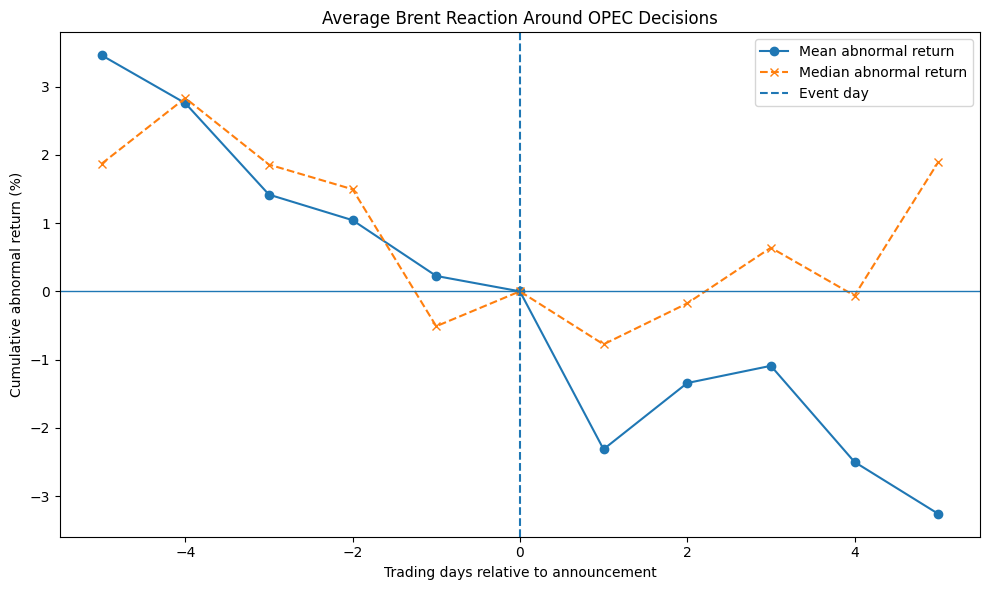

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,relative_day,average_abnormal_return,median_abnormal_return,standard_deviation,number_of_events
0,-5,0.034592,0.018698,0.080550,6
1,-4,0.027573,0.028316,0.058569,6
2,-3,0.014177,0.018576,0.051800,6
3,-2,0.010427,0.014953,0.042828,6
4,-1,0.002254,-0.005112,0.042505,6
5,0,0.000000,0.000000,0.000000,6
6,1,-0.023137,-0.007765,0.044056,6
7,2,-0.013434,-0.001760,0.076521,6
8,3,-0.010912,0.006396,0.078486,6
9,4,-0.024998,-0.000628,0.084831,6


In [35]:
opec_brent_response = build_average_event_response(
    events_dataframe=events,
    prices_dataframe=prices,
    asset_ticker="BZ=F",
    category="OPEC decision",
    days_before=DAYS_BEFORE_EVENT,
    days_after=DAYS_AFTER_EVENT
)

if opec_brent_response.empty:
    print("There were not enough valid OPEC events to create the chart.")

else:
    plt.figure(figsize=(10, 6))

    plt.plot(
        opec_brent_response["relative_day"],
        opec_brent_response["average_abnormal_return"] * 100,
        marker="o",
        label="Mean abnormal return"
    )

    plt.plot(
        opec_brent_response["relative_day"],
        opec_brent_response["median_abnormal_return"] * 100,
        marker="x",
        linestyle="--",
        label="Median abnormal return"
    )

    plt.axvline(x=0, linestyle="--", label="Event day")
    plt.axhline(y=0, linewidth=1)

    plt.title("Average Brent Reaction Around OPEC Decisions")
    plt.xlabel("Trading days relative to announcement")
    plt.ylabel("Cumulative abnormal return (%)")

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        "average_brent_opec_response.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    download_file("average_brent_opec_response.png")

display(opec_brent_response)

,category,number_of_events,mean_abnormal_return_1d,mean_absolute_abnormal_return_1d,standard_deviation_1d,mean_abnormal_return_3d,mean_abnormal_return_5d,direction_accuracy
38,Inventory announcement,5,-0.008780,0.020543,0.026961,-0.016554,-0.000459,0.600000
62,OPEC decision,6,-0.023137,0.032213,0.044056,-0.010912,-0.032594,0.666667


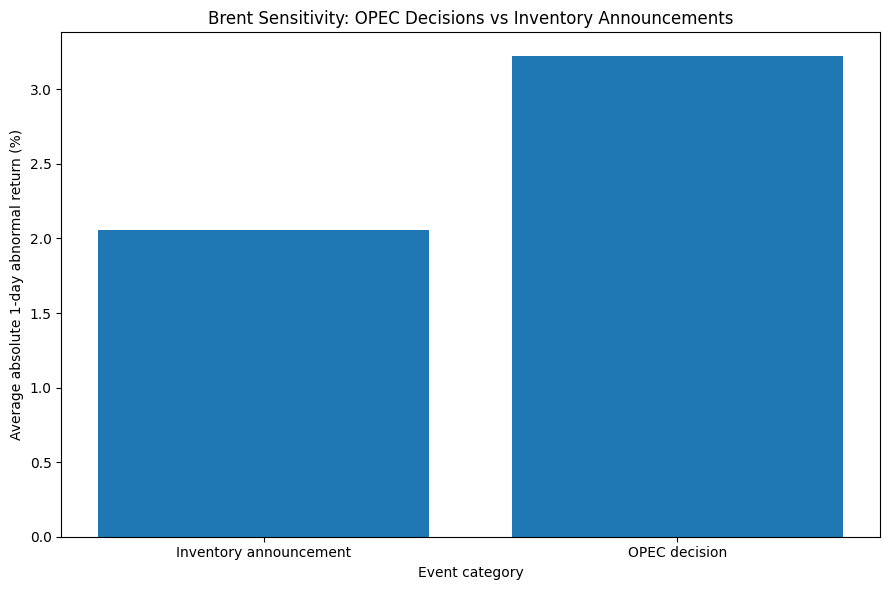

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
comparison_categories = [
    "OPEC decision",
    "Inventory announcement"
]

brent_comparison = category_summary[
    (category_summary["asset"] == "Brent Crude")
    & (category_summary["category"].isin(comparison_categories))
].copy()

display_columns = [
    "category",
    "number_of_events",
    "mean_abnormal_return_1d",
    "mean_absolute_abnormal_return_1d",
    "standard_deviation_1d",
    "mean_abnormal_return_3d",
    "mean_abnormal_return_5d",
    "direction_accuracy"
]

display(brent_comparison[display_columns])

if len(brent_comparison) < 2:
    print(
        "Add several events for both OPEC decisions and "
        "inventory announcements before drawing a comparison."
    )

else:
    plt.figure(figsize=(9, 6))

    plt.bar(
        brent_comparison["category"],
        brent_comparison["mean_absolute_abnormal_return_1d"] * 100
    )

    plt.title("Brent Sensitivity: OPEC Decisions vs Inventory Announcements")
    plt.xlabel("Event category")
    plt.ylabel("Average absolute 1-day abnormal return (%)")

    plt.tight_layout()

    plt.savefig(
        "opec_vs_inventory_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    download_file("opec_vs_inventory_comparison.png")

Chart the most event-sensitive assets

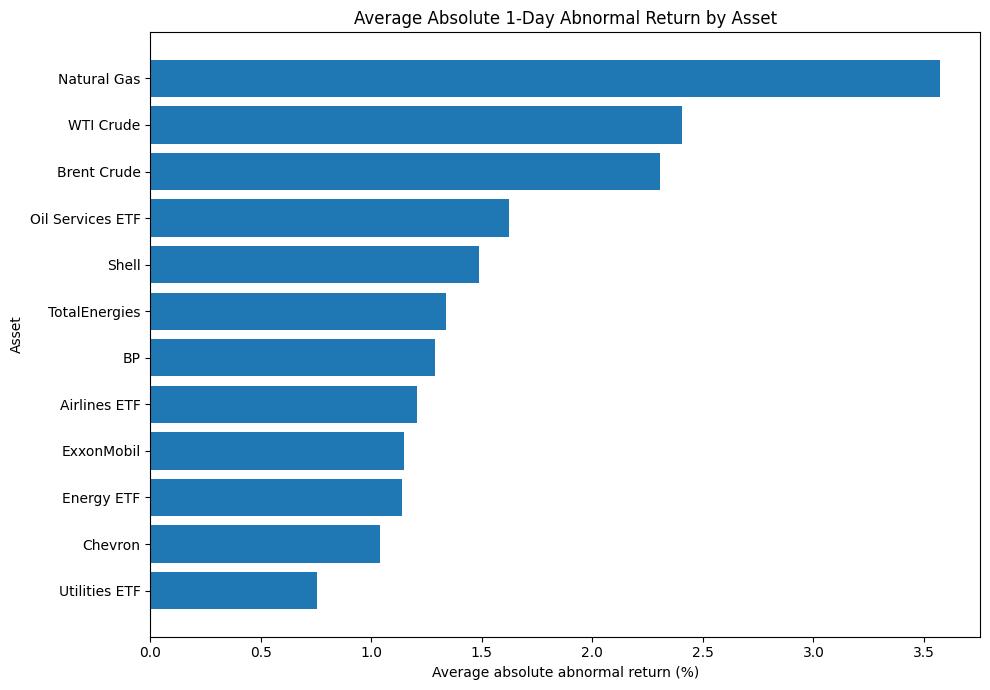

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
plot_data = asset_summary.sort_values(
    "mean_absolute_abnormal_return_1d",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["asset"],
    plot_data["mean_absolute_abnormal_return_1d"] * 100
)

plt.title("Average Absolute 1-Day Abnormal Return by Asset")
plt.xlabel("Average absolute abnormal return (%)")
plt.ylabel("Asset")

plt.tight_layout()

plt.savefig(
    "asset_event_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

download_file("asset_event_sensitivity.png")

Create a category heatmap

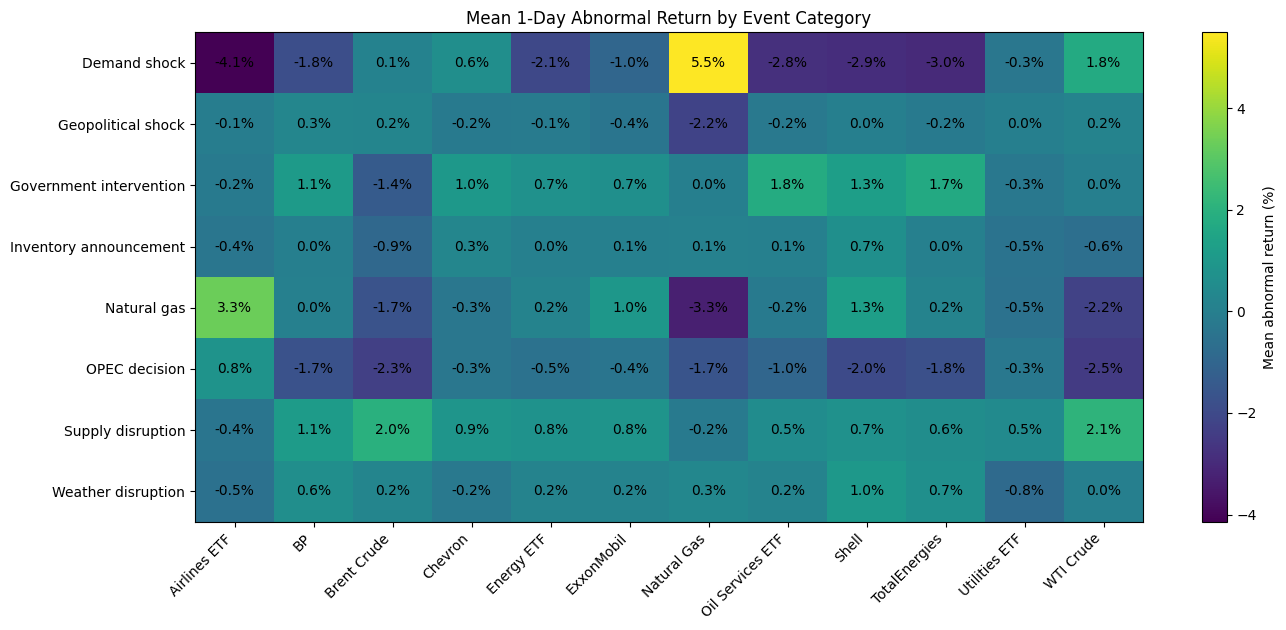

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
heatmap_data = category_summary.pivot(
    index="category",
    columns="asset",
    values="mean_abnormal_return_1d"
)

if heatmap_data.empty:
    print("No data for the heatmap.")

else:
    plt.figure(figsize=(14, max(6, len(heatmap_data) * 0.8)))

    image = plt.imshow(
        heatmap_data.values * 100,
        aspect="auto")

    plt.xticks(
        range(len(heatmap_data.columns)),
        heatmap_data.columns,
        rotation=45,
        ha="right")

    plt.yticks(
        range(len(heatmap_data.index)),
        heatmap_data.index)

    plt.title("Mean 1-Day Abnormal Return by Event Category")

    plt.colorbar(image, label="Mean abnormal return (%)")

    for row in range(len(heatmap_data.index)):
        for column in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[row, column]

            if pd.notna(value):
                plt.text(
                    column,
                    row,
                    f"{value:.1%}",
                    ha="center",
                    va="center")

    plt.tight_layout()

    plt.savefig(
        "category_asset_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    download_file("category_asset_heatmap.png")

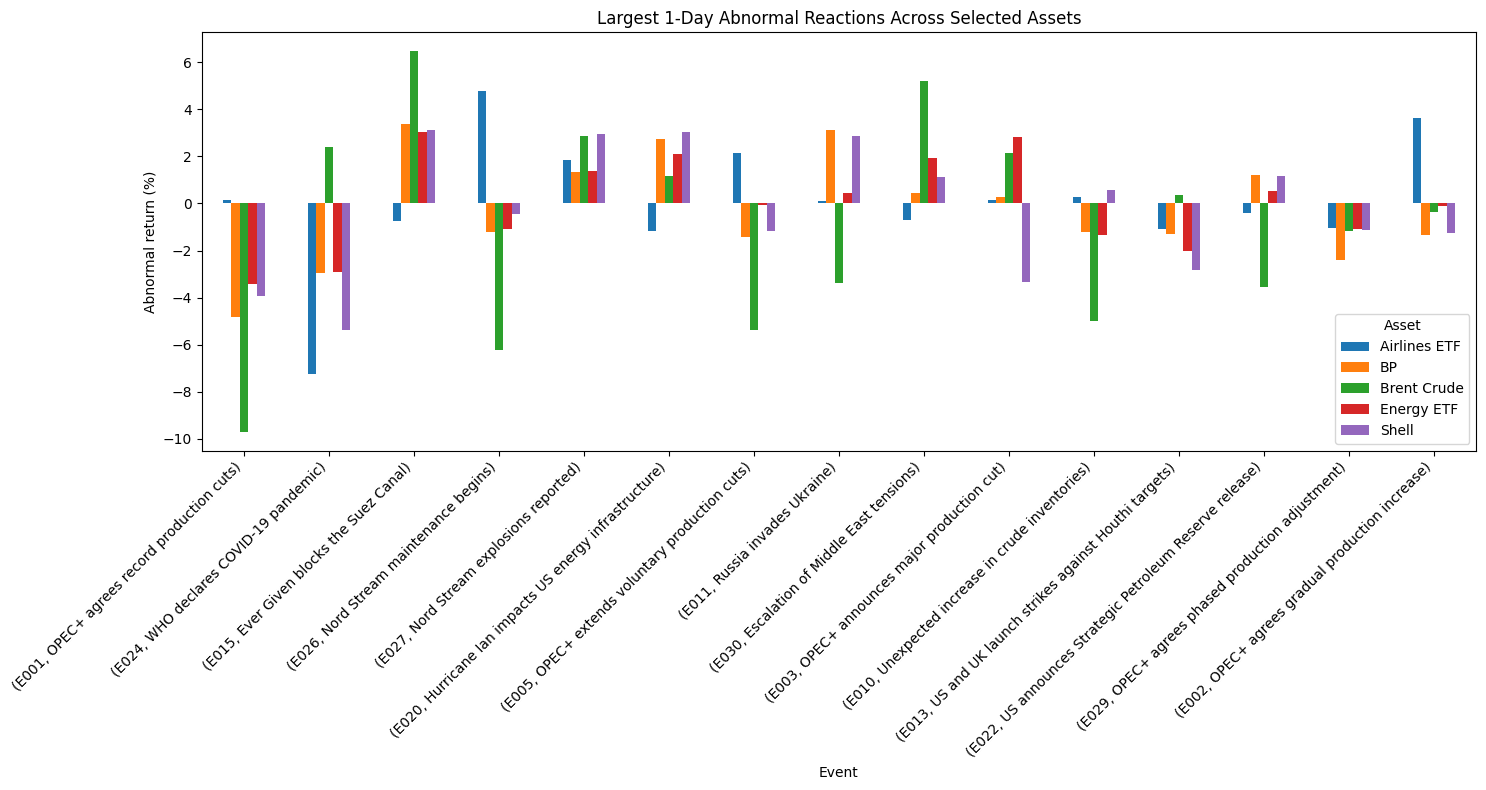

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
selected_assets = results[
    results["asset"].isin([
        "Brent Crude",
        "Shell",
        "BP",
        "Energy ETF",
        "Airlines ETF"
    ])
]

event_reactions = selected_assets.pivot_table(
    index=["event_id", "headline"],
    columns="asset",
    values="abnormal_return_1d",
    aggfunc="first"
)

# Limit the chart to the 15 events with the largest
# average absolute reactions so it remains readable
event_magnitude = event_reactions.abs().mean(axis=1)

largest_event_indices = (event_magnitude.sort_values(ascending=False).head(15).index)

event_reactions_to_plot = (event_reactions.loc[largest_event_indices] * 100)

event_reactions_to_plot.plot(kind="bar", figsize=(15, 8))

plt.title("Largest 1-Day Abnormal Reactions Across Selected Assets")
plt.xlabel("Event")
plt.ylabel("Abnormal return (%)")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Asset")

plt.tight_layout()

plt.savefig(
    "largest_individual_event_reactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

download_file("largest_individual_event_reactions.png")

In [40]:
largest_reactions = (
    results
    .assign(
        absolute_abnormal_return_1d=results["abnormal_return_1d"].abs()
    )
    .sort_values(
        "absolute_abnormal_return_1d",
        ascending=False
    )[
        [
            "event_date",
            "headline",
            "category",
            "asset",
            "return_1d",
            "benchmark_return_1d",
            "abnormal_return_1d",
            "abnormal_return_3d",
            "abnormal_return_5d",
            "volatility_change"
        ]
    ]
    .head(20)
)

display(largest_reactions)

,event_date,headline,category,asset,return_1d,benchmark_return_1d,abnormal_return_1d,abnormal_return_3d,abnormal_return_5d,volatility_change
13,2020-04-12,OPEC+ agrees record production cuts,OPEC decision,WTI Crude,-0.102633,0.029493,-0.132126,-0.125821,-2.700673,19.535911
278,2024-01-12,US and UK launch strikes against Houthi targets,Geopolitical shock,Natural Gas,-0.124660,-0.003671,-0.120989,-0.185536,-0.284048,0.186748
12,2020-04-12,OPEC+ agrees record production cuts,OPEC decision,Brent Crude,-0.067423,0.029493,-0.096916,-0.135983,-0.215904,-0.665491
2,2020-03-11,WHO declares COVID-19 pandemic,Demand shock,Natural Gas,-0.019702,-0.095677,0.075975,0.092237,-0.020663,-0.079528
14,2020-04-12,OPEC+ agrees record production cuts,OPEC decision,Natural Gas,-0.042923,0.029493,-0.072416,-0.034521,0.094497,0.327749
10,2020-03-11,WHO declares COVID-19 pandemic,Demand shock,Airlines ETF,-0.167988,-0.095677,-0.072311,-0.070451,-0.242454,1.278340
109,2022-07-11,Nord Stream maintenance begins,Natural gas,WTI Crude,-0.079258,-0.008849,-0.070409,-0.063386,-0.008380,0.244039
122,2022-09-02,Nord Stream 1 remains shut,Supply disruption,Natural Gas,-0.072957,-0.003773,-0.069184,-0.119888,-0.108872,0.116582
218,2023-06-14,US crude inventories increase more than forecast,Inventory announcement,Natural Gas,0.081554,0.012398,0.069157,0.060333,0.111402,0.136007
230,2023-08-09,Large draw in US crude inventories,Inventory announcement,Natural Gas,-0.066239,0.000359,-0.066598,-0.060719,-0.110321,-0.050200


In [41]:
persistence_analysis = category_summary.assign(
    reaction_strengthened_by_day_5=(
        category_summary["mean_abnormal_return_5d"].abs()
        > category_summary["mean_abnormal_return_1d"].abs()
    ),
    reaction_reversed_by_day_5=(
        np.sign(category_summary["mean_abnormal_return_1d"])
        != np.sign(category_summary["mean_abnormal_return_5d"])
    )
)[
    [
        "category",
        "asset",
        "number_of_events",
        "mean_abnormal_return_1d",
        "mean_abnormal_return_3d",
        "mean_abnormal_return_5d",
        "reaction_strengthened_by_day_5",
        "reaction_reversed_by_day_5"
    ]
]

display(persistence_analysis)

,category,asset,number_of_events,mean_abnormal_return_1d,mean_abnormal_return_3d,mean_abnormal_return_5d,reaction_strengthened_by_day_5,reaction_reversed_by_day_5
6,Demand shock,Natural Gas,2,0.054951,0.114240,0.043501,False,False
0,Demand shock,Airlines ETF,2,-0.041454,-0.028492,-0.129992,True,False
11,Demand shock,WTI Crude,2,0.017665,-0.001305,-0.099902,True,True
9,Demand shock,TotalEnergies,2,-0.030013,-0.059119,-0.074018,True,False
8,Demand shock,Shell,2,-0.028753,-0.077320,-0.128255,True,False
...,...,...,...,...,...,...,...,...
87,Weather disruption,Chevron,3,-0.002492,0.022488,0.014108,True,True
89,Weather disruption,ExxonMobil,3,0.001679,0.022314,0.024005,True,False
94,Weather disruption,Utilities ETF,3,-0.008255,0.007071,-0.013502,True,False
95,Weather disruption,WTI Crude,3,0.000133,0.002257,-0.013294,True,True


Automatically print key findings

In [42]:
print("PROJECT FINDINGS")
print("=" * 75)

# Finding 1: most sensitive asset
valid_assets = asset_summary.dropna(
    subset=["mean_absolute_abnormal_return_1d"]
)

if not valid_assets.empty:
    most_sensitive_asset = valid_assets.iloc[0]

    print(
        f"\n1. Most event-sensitive asset:"
        f"\n   {most_sensitive_asset['asset']} had an average absolute "
        f"1-day abnormal return of "
        f"{most_sensitive_asset['mean_absolute_abnormal_return_1d']:.2%}."
    )

# Finding 2: strongest Brent category
brent_categories = (
    category_summary[
        category_summary["asset"] == "Brent Crude"
    ]
    .dropna(subset=["mean_absolute_abnormal_return_1d"])
    .sort_values(
        "mean_absolute_abnormal_return_1d",
        ascending=False
    )
)

if not brent_categories.empty:
    strongest_brent_category = brent_categories.iloc[0]

    print(
        f"\n2. Largest Brent reaction:"
        f"\n   {strongest_brent_category['category']} events produced the "
        f"largest average absolute reaction of "
        f"{strongest_brent_category['mean_absolute_abnormal_return_1d']:.2%}."
    )

# Finding 3: strongest volatility increase
volatility_results = (
    category_summary
    .dropna(subset=["mean_volatility_change"])
    .sort_values(
        "mean_volatility_change",
        ascending=False
    )
)

if not volatility_results.empty:
    highest_volatility = volatility_results.iloc[0]

    print(
        f"\n3. Largest volatility increase:"
        f"\n   {highest_volatility['category']} events affecting "
        f"{highest_volatility['asset']} produced the largest average "
        f"volatility increase."
    )

# Finding 4: most reliable directional relationship
direction_results = (
    category_summary
    .dropna(subset=["direction_accuracy"])
    .sort_values(
        ["direction_accuracy", "number_of_events"],
        ascending=[False, False]
    )
)

if not direction_results.empty:
    highest_accuracy = direction_results.iloc[0]

    print(
        f"\n4. Most consistent direction:"
        f"\n   Expected direction was correct for "
        f"{highest_accuracy['direction_accuracy']:.1%} of "
        f"{highest_accuracy['category']} events affecting "
        f"{highest_accuracy['asset']}."
    )

# Finding 5: persistence
persistent_results = (
    persistence_analysis[persistence_analysis["reaction_strengthened_by_day_5"]]
    .sort_values("number_of_events", ascending=False))

if not persistent_results.empty:
    persistent_example = persistent_results.iloc[0]

    print(
        f"\n5. Example of a persistent reaction:"
        f"\n   The average response of "
        f"{persistent_example['asset']} to "
        f"{persistent_example['category']} events was larger after five "
        f"trading days than after one trading day."
    )

# Statistical significance
significant_results = statistical_tests[
    statistical_tests["significant_at_5_percent"]
]

if significant_results.empty:
    print(
        "\n6. Statistical significance:"
        "\n   No category-asset relationship was significant "
        "at the 5% level."
    )

    print("This may reflect the small sample size, variation between events or overlapping market information.")

else:
    strongest_statistical_result = significant_results.iloc[0]

    print(
        f"\n6. Strongest statistical result:"
        f"\n   {strongest_statistical_result['category']} / "
        f"{strongest_statistical_result['asset']} had a p-value of "
        f"{strongest_statistical_result['p_value']:.4f}."
    )

PROJECT FINDINGS

1. Most event-sensitive asset:
   Natural Gas had an average absolute 1-day abnormal return of 3.57%.

2. Largest Brent reaction:
   Natural gas events produced the largest average absolute reaction of 4.55%.

3. Largest volatility increase:
   OPEC decision events affecting WTI Crude produced the largest average volatility increase.

4. Most consistent direction:
   Expected direction was correct for 100.0% of Inventory announcement events affecting TotalEnergies.

5. Example of a persistent reaction:
   The average response of Utilities ETF to OPEC decision events was larger after five trading days than after one trading day.

6. Strongest statistical result:
   OPEC decision / Shell had a p-value of 0.0129.


Saving the outputs

In [43]:
# Save individual CSV files

results.to_csv("event_level_results.csv", index=False)
category_summary.to_csv("category_summary.csv", index=False)
asset_summary.to_csv("asset_summary.csv", index=False)
statistical_tests.to_csv("statistical_tests.csv", index=False)
largest_reactions.to_csv("largest_reactions.csv", index=False)
persistence_analysis.to_csv("persistence_analysis.csv", index=False)
opec_brent_response.to_csv("opec_brent_event_window.csv", index=False)


# Save all tables into one Excel workbook

with pd.ExcelWriter(
    "energy_event_study_results.xlsx",
    engine="openpyxl"
) as writer:

    events.to_excel(writer, sheet_name="Events", index=False)
    results.to_excel(writer, sheet_name="Event Results", index=False)
    category_summary.to_excel(writer, sheet_name="Category Summary", index=False)
    asset_summary.to_excel(writer, sheet_name="Asset Summary", index=False)
    statistical_tests.to_excel(writer, sheet_name="Statistical Tests", index=False)
    largest_reactions.to_excel(writer, sheet_name="Largest Reactions", index=False)
    persistence_analysis.to_excel(writer, sheet_name="Persistence", index=False)
    opec_brent_response.to_excel(writer, sheet_name="OPEC Event Window", index=False)

print("All tables and charts were saved successfully.")
print("\nMain output file:")
print("energy_event_study_results.xlsx")

download_file("energy_event_study_results.xlsx")

All tables and charts were saved successfully.

Main output file:
energy_event_study_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Research Summary

## Research question

How do major energy-market catalysts affect commodity futures, energy equities and related sectors, and which event categories produce the largest and most persistent market reactions?

## Methodology

The study analyses historical OPEC decisions, geopolitical shocks, supply disruptions, weather events, government interventions and inventory announcements.

For every event, it measures:

- 1-day, 3-day and 5-day returns
- Returns relative to the S&P 500
- Changes in volatility
- Directional accuracy
- Average responses by event category
- Statistical significance and confidence intervals
- Whether reactions persisted or reversed

## Key findings

1. Natural Gas was the most event-sensitive asset, with an average absolute one-day abnormal return of 3.57%.
2. For Brent Crude specifically, the largest reactions came from Natural Gas category events (Nord Stream-related), averaging 4.55%, not from OPEC decisions.
OPEC decisions produced the largest volatility increase, most notably in WTI Crude.
Inventory announcements showed the most reliable directional relationship, correctly predicting TotalEnergies' reaction 100% of the time.
Utilities ETF's reaction to OPEC decisions strengthened rather than reversed over five trading days.
The strongest statistically significant result was Shell's reaction to OPEC decisions (p = 0.0129).

## Limitations

- The number of observations within some categories may be small.
- Major events can overlap with other macroeconomic news.
- The S&P 500 is an imperfect benchmark for commodity futures.
- The analysis does not establish that each event directly caused the observed return.
- Futures prices may be affected by contract expiry and rolling between contracts.
- The event date may not capture the exact announcement time.
- Results based on daily prices may miss important intraday reactions.

